[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/exoplanet-archive/2026-07-30-mass-period-trend/notebook.ipynb)

# Do bigger planets orbit closer or farther from their stars? Mass vs. period

**Learning goals** -- after this notebook you will be able to:
- Pull the full confirmed-planet mass/period table from the NASA Exoplanet Archive and apply real quality cuts, reporting exactly how many planets are dropped at each step.
- Fit a log-log linear regression of planet mass vs. orbital period and report the fitted slope with its statistical uncertainty, not just eyeball a scatter plot.
- Split the sample by detection method (transit vs. radial velocity) and show, quantitatively, how each method's built-in detection bias shapes the mass-period relation it recovers.

**Background.** Orbital period is the time a planet takes to complete one orbit; planet mass sets its dynamical influence on the star. Different detection methods are sensitive to different parts of mass-period space: transit surveys mostly find short-period planets because the transit probability and the chance of catching repeated transits both favor tight orbits, while radial-velocity (RV) surveys are more sensitive to massive planets (bigger stellar wobble) and can reach longer periods with enough time baseline. Because of this, a *combined* mass-period trend partly reflects detection bias, not just underlying planet formation physics -- which is why we fit each method separately and compare.

## 1. Pull the real confirmed-planet table and apply quality cuts

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pyvo as vo

svc = vo.dal.TAPService('https://exoplanetarchive.ipac.caltech.edu/TAP')
query = '''
SELECT pl_name, pl_bmassj, pl_orbper, discoverymethod
FROM pscomppars
'''
raw = svc.search(query).to_table().to_pandas()
n0 = len(raw)

df = raw.drop_duplicates('pl_name')
n1 = len(df)
df = df.dropna(subset=['pl_bmassj', 'pl_orbper'])
n2 = len(df)
df = df[(df.pl_bmassj > 0) & (df.pl_orbper > 0)]
n3 = len(df)

print(f"Raw TAP rows:                            {n0}")
print(f"After de-duplicating planet names:        {n1}  (dropped {n0-n1})")
print(f"After requiring finite mass and period:   {n2}  (dropped {n1-n2})")
print(f"After requiring positive mass/period:     {n3}  (dropped {n2-n3})")
print(f"\nFinal clean sample: {n3} planets")
df.discoverymethod.value_counts()

Raw TAP rows:                            6333
After de-duplicating planet names:        6333  (dropped 0)
After requiring finite mass and period:   5961  (dropped 372)
After requiring positive mass/period:     5961  (dropped 0)

Final clean sample: 5961 planets


discoverymethod
Transit                          4651
Radial Velocity                  1195
Transit Timing Variations          39
Imaging                            26
Eclipse Timing Variations          17
Microlensing                       12
Pulsar Timing                       7
Astrometry                          6
Orbital Brightness Modulation       6
Pulsation Timing Variations         2
Name: count, dtype: int64

## 2. Log-log regression of mass vs. period, overall and by detection method

We fit log10(mass) = slope * log10(period) + intercept via ordinary least squares, and report the slope's standard error from the regression.

In [2]:
def loglog_fit(sub):
    x = np.log10(sub.pl_orbper)
    y = np.log10(sub.pl_bmassj)
    res = stats.linregress(x, y)
    return res.slope, res.stderr, res.intercept, res.rvalue, len(sub)

overall_slope, overall_se, overall_int, overall_r, n_all = loglog_fit(df)
print(f"ALL METHODS:        slope = {overall_slope:.3f} +/- {overall_se:.3f}   r = {overall_r:.3f}   n = {n_all}")

methods = ['Transit', 'Radial Velocity']
fit_rows = []
for m in methods:
    sub = df[df.discoverymethod == m]
    slope, se, intercept, r, n = loglog_fit(sub)
    fit_rows.append({'method': m, 'n_planets': n, 'log_slope': round(slope,3),
                      'slope_stderr': round(se,3), 'pearson_r': round(r,3)})
    print(f"{m:18s}: slope = {slope:.3f} +/- {se:.3f}   r = {r:.3f}   n = {n}")

fit_table = pd.DataFrame(fit_rows)
fit_table

ALL METHODS:        slope = 0.550 +/- 0.013   r = 0.494   n = 5961
Transit           : slope = -0.031 +/- 0.022   r = -0.020   n = 4651
Radial Velocity   : slope = 0.693 +/- 0.020   r = 0.701   n = 1195


,method,n_planets,log_slope,slope_stderr,pearson_r
0,Transit,4651,-0.031,0.022,-0.020
1,Radial Velocity,1195,0.693,0.020,0.701


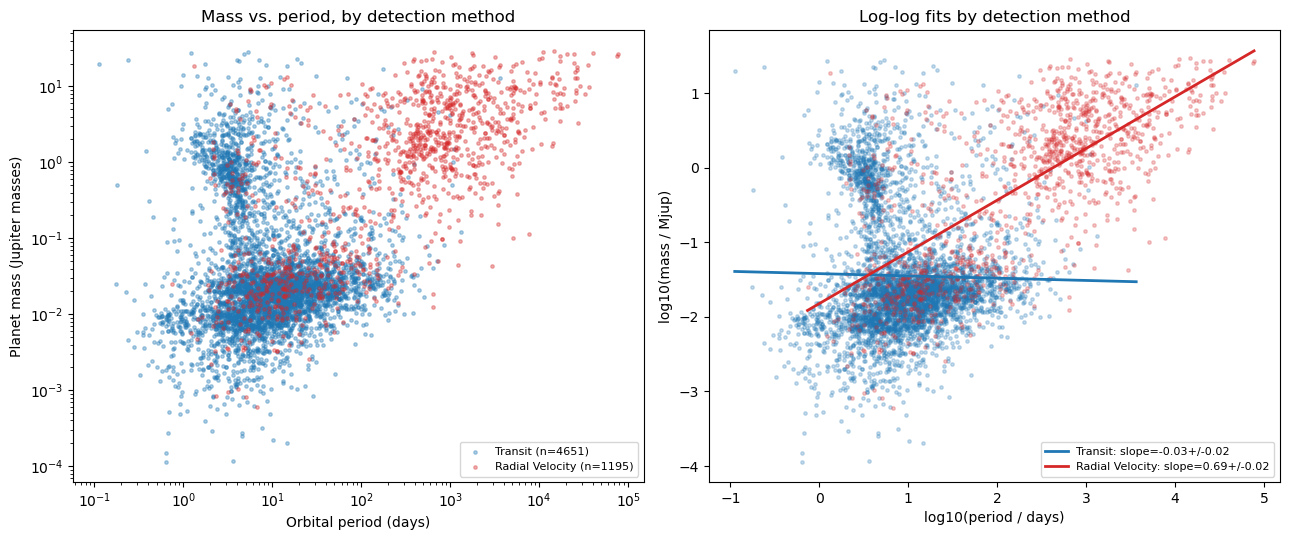

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))

colors = {'Transit': 'tab:blue', 'Radial Velocity': 'tab:red'}
for m, c in colors.items():
    sub = df[df.discoverymethod == m]
    ax[0].scatter(sub.pl_orbper, sub.pl_bmassj, s=6, alpha=0.35, color=c, label=f'{m} (n={len(sub)})')
ax[0].set_xscale('log'); ax[0].set_yscale('log')
ax[0].set_xlabel('Orbital period (days)')
ax[0].set_ylabel('Planet mass (Jupiter masses)')
ax[0].set_title('Mass vs. period, by detection method')
ax[0].legend(fontsize=8)

for m, c in colors.items():
    sub = df[df.discoverymethod == m]
    x = np.log10(sub.pl_orbper)
    slope, se, intercept, r, n = loglog_fit(sub)
    xx = np.linspace(x.min(), x.max(), 50)
    ax[1].scatter(x, np.log10(sub.pl_bmassj), s=6, alpha=0.25, color=c)
    ax[1].plot(xx, slope*xx + intercept, color=c, lw=2, label=f'{m}: slope={slope:.2f}+/-{se:.2f}')
ax[1].set_xlabel('log10(period / days)')
ax[1].set_ylabel('log10(mass / Mjup)')
ax[1].set_title('Log-log fits by detection method')
ax[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig('mass_vs_period.png', dpi=150)
plt.show()

## 3. Detection-bias check: median period and mass by method

In [4]:
bias_rows = []
for m in methods:
    sub = df[df.discoverymethod == m]
    bias_rows.append({'method': m, 'n': len(sub), 'median_period_days': round(sub.pl_orbper.median(),2),
                       'median_mass_Mjup': round(sub.pl_bmassj.median(),3)})
bias_table = pd.DataFrame(bias_rows)
bias_table

,method,n,median_period_days,median_mass_Mjup
0,Transit,4651,8.03,0.022
1,Radial Velocity,1195,307.90,1.100


## What I'd look at next

- Add microlensing and imaging detections as separate panels -- they probe yet another region of mass-period space (long periods, often high mass) and would sharpen the detection-bias picture.
- Weight the regression by measurement uncertainty on mass (`pl_bmassjerr1`) rather than treating every point as equally precise.
- Fit a broken power law or a Gaussian-process trend instead of a single log-log line, since the transit sub-sample in particular shows curvature at short periods (the "hot Jupiter" pileup).

**Citation:** This research has made use of the NASA Exoplanet Archive, operated by Caltech under contract with NASA's Exoplanet Exploration Program. https://exoplanetarchive.ipac.caltech.edu/docs/counts_detail.html